In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

print('Ready!')

Ready!


In [2]:
# Load ALL results — both ML and DL
results = []
for filename in os.listdir('results/metrics'):
    if filename.endswith('.json'):
        with open(f'results/metrics/{filename}') as f:
            results.append(json.load(f))

df_all = pd.DataFrame(results)

# Add model type column
ml_models = ['logistic_regression', 'svm', 'random_forest']
dl_models  = ['lstm', 'bilstm', 'gru']

df_all['model_type'] = df_all['model'].apply(
    lambda x: 'Classical ML' if x in ml_models else 'Deep Learning'
)

print(df_all[['dataset', 'model', 'model_type', 'f1']].to_string(index=False))

dataset               model    model_type     f1
  cssrs              bilstm Deep Learning 0.5487
  cssrs                 gru Deep Learning 0.5739
  cssrs logistic_regression  Classical ML 0.7060
  cssrs                lstm Deep Learning 0.3988
  cssrs       random_forest  Classical ML 0.6476
  cssrs                 svm  Classical ML 0.7270
 reddit              bilstm Deep Learning 0.9425
 reddit                 gru Deep Learning 0.9415
 reddit logistic_regression  Classical ML 0.9411
 reddit                lstm Deep Learning 0.9364
 reddit       random_forest  Classical ML 0.9083
 reddit                 svm  Classical ML 0.9396
twitter              bilstm Deep Learning 0.8607
twitter                 gru Deep Learning 0.4873
twitter logistic_regression  Classical ML 0.8839
twitter                lstm Deep Learning 0.4873
twitter       random_forest  Classical ML 0.9349
twitter                 svm  Classical ML 0.9194


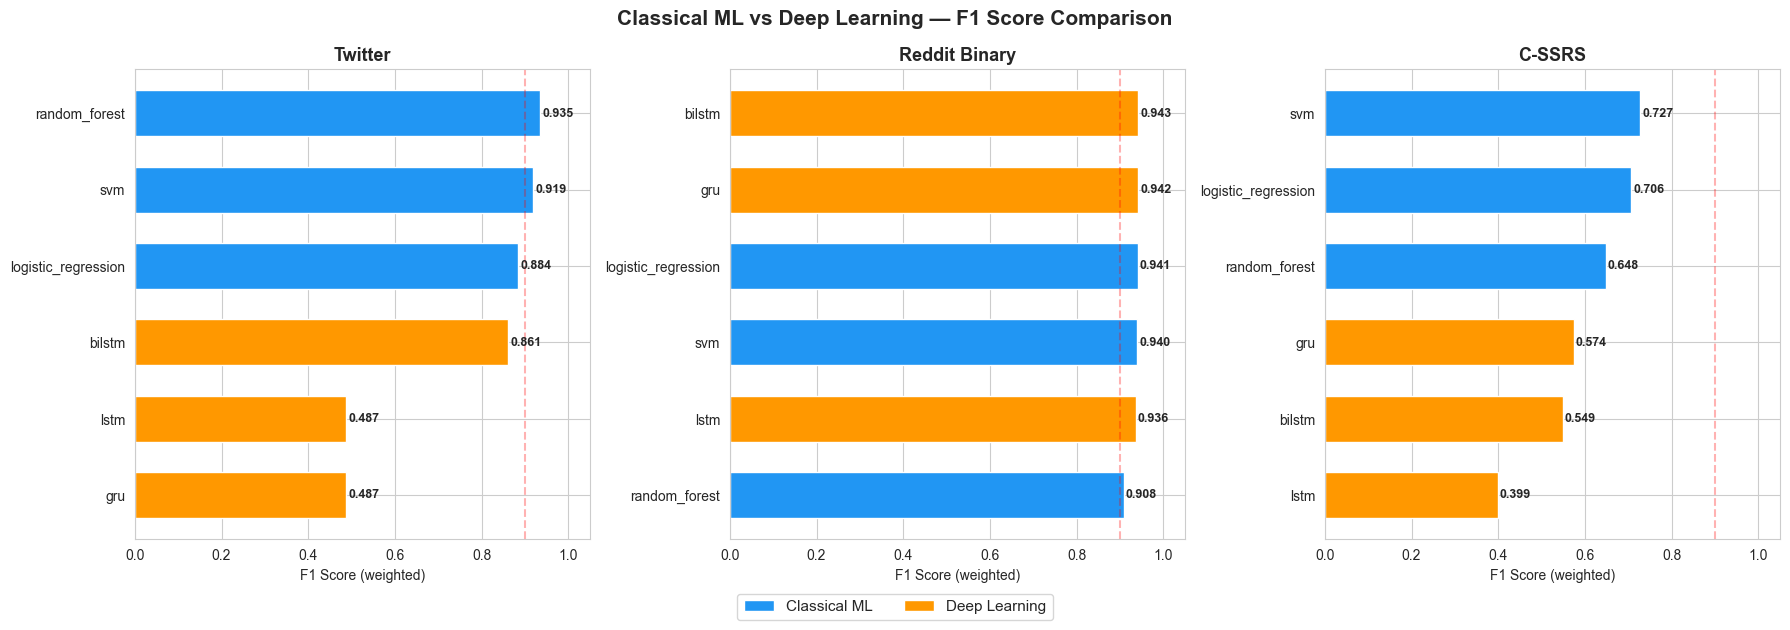

Saved!


In [3]:
# ML vs DL comparison — grouped by dataset
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Classical ML vs Deep Learning — F1 Score Comparison',
             fontsize=15, fontweight='bold')

colors = {'Classical ML': '#2196F3', 'Deep Learning': '#FF9800'}
datasets = ['twitter', 'reddit', 'cssrs']
titles = ['Twitter', 'Reddit Binary', 'C-SSRS']

for ax, dataset, title in zip(axes, datasets, titles):
    subset = df_all[df_all['dataset'] == dataset].sort_values('f1', ascending=True)
    
    bar_colors = [colors[t] for t in subset['model_type']]
    bars = ax.barh(subset['model'], subset['f1'],
                   color=bar_colors, edgecolor='white', height=0.6)
    
    # Add value labels
    for bar, val in zip(bars, subset['f1']):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9, fontweight='bold')
    
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.set_xlabel('F1 Score (weighted)')
    ax.set_xlim(0, 1.05)
    ax.axvline(x=0.9, color='red', linestyle='--', alpha=0.3)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2196F3', label='Classical ML'),
                   Patch(facecolor='#FF9800', label='Deep Learning')]
fig.legend(handles=legend_elements, loc='lower center',
           ncol=2, fontsize=11, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
os.makedirs('results/plots', exist_ok=True)
plt.savefig('results/plots/ml_vs_dl_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved!')

In [ ]:
# Heatmap — все модели и датасеты в одной картинке
pivot = df_all.pivot(index='model', columns='dataset', values='f1')

# Sort by model type then by mean F1
pivot['mean'] = pivot.mean(axis=1)
pivot = pivot.sort_values('mean', ascending=False).drop(columns='mean')

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0.4, vmax=1.0, ax=ax, linewidths=0.5,
            annot_kws={'size': 11})

ax.set_title('All Models — F1 Score Heatmap\n(Classical ML + Deep Learning)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Dataset', fontsize=12)
ax.set_ylabel('Model', fontsize=12)

plt.tight_layout()
plt.savefig('results/plots/all_models_heatmap.png', dpi=150)
plt.show()
print('Saved!')